In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# change path if needed
df = pd.read_csv("../data/train.csv")
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [8]:


print(df.shape)
df.info()
df.describe()

(50120, 55)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50120 entries, 0 to 50119
Data columns (total 55 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Elevation                           50120 non-null  int64
 1   Aspect                              50120 non-null  int64
 2   Slope                               50120 non-null  int64
 3   Horizontal_Distance_To_Hydrology    50120 non-null  int64
 4   Vertical_Distance_To_Hydrology      50120 non-null  int64
 5   Horizontal_Distance_To_Roadways     50120 non-null  int64
 6   Hillshade_9am                       50120 non-null  int64
 7   Hillshade_Noon                      50120 non-null  int64
 8   Hillshade_3pm                       50120 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  50120 non-null  int64
 10  Wilderness_Area1                    50120 non-null  int64
 11  Wilderness_Area2                    50120 non-null  int

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,50120.000000,50120.000000,50120.000000,50120.000000,50120.000000,50120.000000,50120.000000,50120.000000,50120.000000,50120.000000,...,50120.000000,50120.000000,50120.000000,50120.000000,50120.000000,50120.000000,50120.000000,50120.000000,50120.000000,50120.000000
mean,2834.154250,141.027035,13.128113,241.725858,40.082682,3263.892598,216.573524,223.459258,138.063168,3548.404469,...,0.013767,0.012291,0.000439,0.002035,0.000200,0.000678,0.015882,0.013109,0.010974,2.459138
std,281.965313,106.341527,7.457464,206.101669,50.024105,1966.910482,24.340829,18.539704,35.162632,1927.352222,...,0.116523,0.110180,0.020947,0.045067,0.014124,0.026037,0.125020,0.113741,0.104180,1.551823
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2679.000000,55.000000,8.000000,85.000000,6.000000,1410.000000,206.000000,215.000000,119.000000,1825.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,2857.000000,112.000000,12.000000,190.000000,25.000000,3127.000000,222.000000,226.000000,140.000000,3598.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3021.000000,207.000000,17.000000,350.000000,59.000000,5076.000000,233.000000,236.000000,159.000000,5282.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


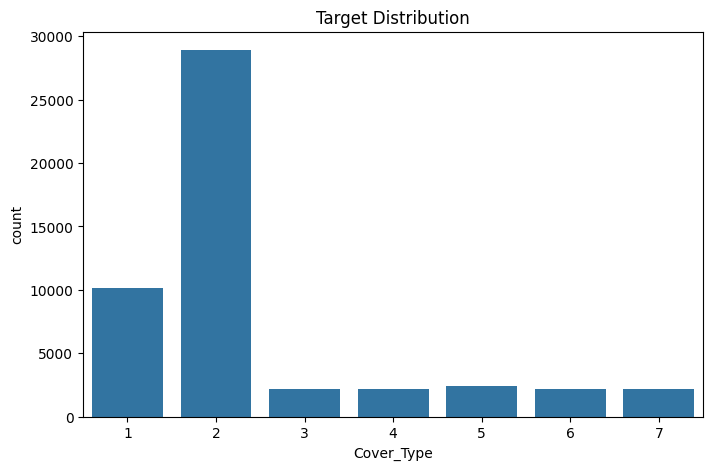

Cover_Type
2    28908
1    10156
5     2416
7     2160
3     2160
6     2160
4     2160
Name: count, dtype: int64


In [9]:

plt.figure(figsize=(8,5))
sns.countplot(x='Cover_Type', data=df)
plt.title("Target Distribution")
plt.show()

print(df['Cover_Type'].value_counts())


In [10]:



print(df.isnull().sum().sum())


0


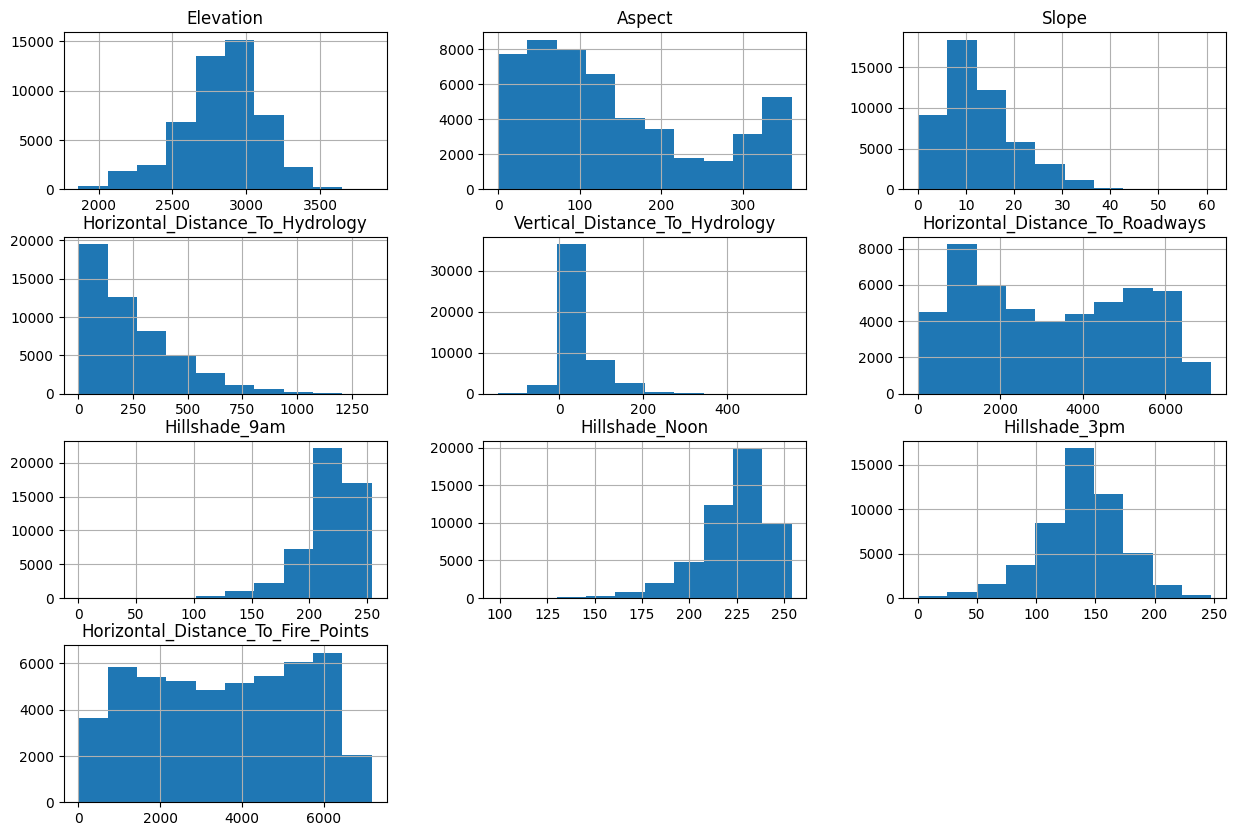

In [11]:



num_cols = [
    'Elevation','Aspect','Slope',
    'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am','Hillshade_Noon','Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

df[num_cols].hist(figsize=(15,10))
plt.show()


In [12]:


wilderness_cols = [c for c in df.columns if 'Wilderness_Area' in c]
soil_cols = [c for c in df.columns if 'Soil_Type' in c]

print(df[wilderness_cols].sum())
print(df[soil_cols].sum())


Wilderness_Area1    38597
Wilderness_Area2      499
Wilderness_Area3     6349
Wilderness_Area4     4675
dtype: int64
Soil_Type1       355
Soil_Type2       623
Soil_Type3       962
Soil_Type4       843
Soil_Type5       165
Soil_Type6       650
Soil_Type7         0
Soil_Type8         1
Soil_Type9        10
Soil_Type10     2142
Soil_Type11      406
Soil_Type12     8281
Soil_Type13      476
Soil_Type14      169
Soil_Type15        0
Soil_Type16     1097
Soil_Type17      612
Soil_Type18     1812
Soil_Type19      191
Soil_Type20     2376
Soil_Type21       16
Soil_Type22      345
Soil_Type23     1911
Soil_Type24     1762
Soil_Type25        1
Soil_Type26       54
Soil_Type27       15
Soil_Type28        9
Soil_Type29    17333
Soil_Type30     3694
Soil_Type31      332
Soil_Type32      690
Soil_Type33      616
Soil_Type34       22
Soil_Type35      102
Soil_Type36       10
Soil_Type37       34
Soil_Type38      796
Soil_Type39      657
Soil_Type40      550
dtype: int64
